# USD SOFR OIS Curve Boostrapping

SOFR zero-coupon rate curve constructed from OIS swaps mirroring the Bloomberg methodology

#### Description: https://quant.stackexchange.com/questions/75671/discrepancy-between-bootstraped-zero-rates-gaps-between-bloomberg-and-my-calcul

In [ ]:
# Approach #1: expilict zero rate formula, resulting dataframe to be exported to excel
# consistent with Bloomberg

import QuantLib as ql
import math
import pandas as pd

calculation_date = ql.Date(26,5,2023)

ql.Settings.instance().evaluationDate = calculation_date

yts = ql.RelinkableYieldTermStructureHandle()
index = ql.OvernightIndex("USD Overnight Index", 0, ql.USDCurrency(), ql.UnitedStates(ql.UnitedStates.Settlement), ql.Actual360(), yts)

swaps = {
    ql.Period("1W"): 0.05064,
    ql.Period("2W"): 0.05067,
    ql.Period("3W"): 0.05072,
    ql.Period("1M"): 0.051021000000000004,
    ql.Period("2M"): 0.051391,
    ql.Period("3M"): 0.051745,
    ql.Period("4M"): 0.05194,
    ql.Period("5M"): 0.051980000000000005,
    ql.Period("6M"): 0.051820000000000005,
    ql.Period("7M"): 0.051584000000000005,
    ql.Period("8M"): 0.05131,
    ql.Period("9M"): 0.050924,
    ql.Period("10M"): 0.050603999999999996,
    ql.Period("11M"): 0.050121,
    ql.Period("12M"): 0.049550000000000004,
    ql.Period("18M"): 0.04558500000000001,
    ql.Period("2Y"): 0.042630999999999995,
    ql.Period("3Y"): 0.038952,
    ql.Period("4Y"): 0.036976,
    ql.Period("5Y"): 0.035919,
    ql.Period("6Y"): 0.03535,
    ql.Period("7Y"): 0.034998,
    ql.Period("8Y"): 0.034808,
    ql.Period("9Y"): 0.034738000000000005,
    ql.Period("10Y"): 0.034712,
    ql.Period("12Y"): 0.034801,
    ql.Period("15Y"): 0.034923,
    ql.Period("20Y"): 0.034662,
    ql.Period("25Y"): 0.03375,
    ql.Period("30Y"): 0.032826,
    ql.Period("40Y"): 0.030834999999999998,
    ql.Period("50Y"): 0.02896
}


rate_helpers = []

for tenor, rate in swaps.items():
    helper = ql.OISRateHelper(2, tenor, ql.QuoteHandle(ql.SimpleQuote(rate)), index)
    rate_helpers.append(helper)

curve = ql.PiecewiseFlatForward(calculation_date, rate_helpers, ql.Actual360())
yts.linkTo(curve)
engine = ql.DiscountingSwapEngine(yts)

# print("maturity |  market  |  model  |  zero rate  |  discount factor |  present value")
tenor_list = [] # dataframe-ready
rate_list = [] # dataframe-ready

for tenor, rate in swaps.items():
    ois_swap = ql.MakeOIS(tenor, index, rate)
    pv = ois_swap.NPV()
    fair_rate = ois_swap.fairRate()
    maturity_date = ois_swap.maturityDate()
    discount_factor = curve.discount(maturity_date)
    zero_rate = -math.log(discount_factor) * 365.0/(maturity_date-calculation_date)
    # Bloomberg methodology: ACT/365 daycount convention, continuous compounding (https://www.r-bloggers.com/2021/07/bootstrapping-the-zero-curve-from-irs-swap-rates-using-r-code/#google_vignette)
    # print(f"   {tenor}    | {rate*100:.6f} | {fair_rate*100:.6f} | {zero_rate*100:.14f} | {discount_factor:.6f} | {pv:.6f}")
   
    tenor_list.append(tenor)
    rate_list.append(float(zero_rate))
    ois_data = pd.DataFrame({"date": tenor_list, "rate": rate_list})
    
ois_data

,date,rate
0,1W,0.051318
1,2W,0.051322
2,3W,0.051343
3,1M,0.051577
4,2M,0.051837
5,3M,0.052078
6,4M,0.052172
7,5M,0.052103
8,6M,0.051845
9,7M,0.051517


In [3]:
# export ois_data to excel

# ois_data.to_excel("C:/Users/jpisa/OneDrive - Vysoká škola ekonomická v Praze/VŠE/Zpracování a analýza dat v Pythonu/Bootstrapping/sofr_swap_curve.xlsx", index=False)

### Actual Zero-Coupon USD SOFR Curve from Bloomberg Terminal:

![Snímek obrazovky 2026-07-13 002349.png](<attachment:Snímek obrazovky 2026-07-13 002349.png>)
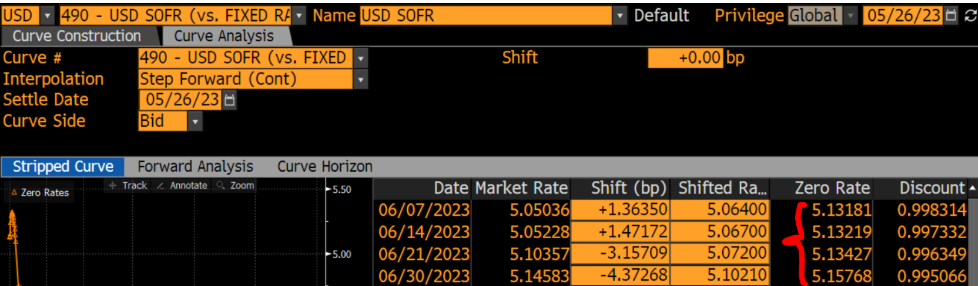

### Zero Rate Curve => built-in QuantLib function closely resembling the Bloomberg curve

In [ ]:
# Approach #2: zero rate determined using a built-in QuantLib function zeroRate(), results printed out

import QuantLib as ql
import math

calculation_date = ql.Date(26,5,2023)

ql.Settings.instance().evaluationDate = calculation_date

yts = ql.RelinkableYieldTermStructureHandle()
index = ql.OvernightIndex("USD Overnight Index", 0, ql.USDCurrency(), ql.UnitedStates(ql.UnitedStates.Settlement), ql.Actual360(), yts)
# OvernightIndex arguments:
# name of the index, number of fixing days => 0 corresponds to the evaluation date, currency (USD), calendar, daycount conventions
# + optional argument yts

# calendar list: https://quantlib-python-docs.readthedocs.io/en/latest/dates.html
# daycount convention list: https://quantlib-python-docs.readthedocs.io/en/latest/dates.html#daycounter 
# currency format: https://quantlib-python-docs.readthedocs.io/en/latest/currencies.html
# fixing date definition: https://www.cftc.gov/sites/default/files/filings/ptc/15/02/ptc022615tradsef003.pdf
# fixing date SOFR OIS (comments): https://www.clarusft.com/sofr-swap-nuances/


# overnight reference rate => SOFR
# custom overnight index in QuantLib: https://quantlib-python-docs.readthedocs.io/en/latest/indexes.html#overnightindex
# alternative for SOFR:
# index = ql.Sofr()

# ql.Period shortcut => swaps = {} redundant ahead of rate_helpers = []
# if data are stored in Excel, use [] version
swaps = {
    ql.Period("1W"): 0.05064,
    ql.Period("2W"): 0.05067,
    ql.Period("3W"): 0.05072,
    ql.Period("1M"): 0.051021000000000004,
    ql.Period("2M"): 0.051391,
    ql.Period("3M"): 0.051745,
    ql.Period("4M"): 0.05194,
    ql.Period("5M"): 0.051980000000000005,
    ql.Period("6M"): 0.051820000000000005,
    ql.Period("7M"): 0.051584000000000005,
    ql.Period("8M"): 0.05131,
    ql.Period("9M"): 0.050924,
    ql.Period("10M"): 0.050603999999999996,
    ql.Period("11M"): 0.050121,
    ql.Period("12M"): 0.049550000000000004,
    ql.Period("18M"): 0.04558500000000001,
    ql.Period("2Y"): 0.042630999999999995,
    ql.Period("3Y"): 0.038952,
    ql.Period("4Y"): 0.036976,
    ql.Period("5Y"): 0.035919,
    ql.Period("6Y"): 0.03535,
    ql.Period("7Y"): 0.034998,
    ql.Period("8Y"): 0.034808,
    ql.Period("9Y"): 0.034738000000000005,
    ql.Period("10Y"): 0.034712,
    ql.Period("12Y"): 0.034801,
    ql.Period("15Y"): 0.034923,
    ql.Period("20Y"): 0.034662,
    ql.Period("25Y"): 0.03375,
    ql.Period("30Y"): 0.032826,
    ql.Period("40Y"): 0.030834999999999998,
    ql.Period("50Y"): 0.02896
}


rate_helpers = []

for tenor, rate in swaps.items():
    helper = ql.OISRateHelper(2, tenor, ql.QuoteHandle(ql.SimpleQuote(rate)), index)
    # OISRateHelper arguments:
    # settlement date convention (T+2), tenor = maturities of swap insturments, quoted swap rates, index = SOFR
    # OIS SOFR swaps payment frequency: https://btrm.org/wp-content/uploads/2024/03/BTRM-WP15_SOFR-OIS-Curve-Construction_Dec-2020.pdf
    rate_helpers.append(helper)

# bootstrapping methods: https://quantlib-python-docs.readthedocs.io/en/latest/termstructures.html#piecewise
# discount factor, or zero rate depending on the chosen class
# PiecewiseLogCubicDiscount => discount factor
# PiecewiseFlatForward => zero rate

curve = ql.PiecewiseFlatForward(calculation_date, rate_helpers, ql.Actual360())
# PiecewiseFlatForward arguments:
# reference date = today, rate_helpers = OIS swaps, daycount convetion

yts.linkTo(curve)
engine = ql.DiscountingSwapEngine(yts)

# properties of the index (SOFR) handle yts linked to the curve object
# object engine prices OIS swaps according to the yts curve
# source: http://quantlibguide.com/Handling%20dependencies.html

print("maturity |  market  |  model  |  zero rate  |  discount factor |  present value")
for tenor, rate in swaps.items():
    ois_swap = ql.MakeOIS(tenor, index, rate)
    # MakeOIS arguments: https://quantlib-python-docs.readthedocs.io/en/latest/instruments.html#makeois
    pv = ois_swap.NPV()
    fair_rate = ois_swap.fairRate() # model equivalent of the quoted swape rate from the object swaps
    maturity_date = ois_swap.maturityDate() # maturity dates of swaps
    discount_factor = curve.discount(maturity_date)
    # discount factors consistent with Bloomberg (see https://www.r-bloggers.com/2021/07/bootstrapping-the-zero-curve-from-irs-swap-rates-using-r-code/#google_vignette)
    zero_rate = curve.zeroRate(maturity_date, ql.Actual365Fixed(), ql.Continuous).rate()
    # zero_rate almost identical as the same object in the previous Approach
    print(f"   {tenor}    | {rate*100:.6f} | {fair_rate*100:.6f} | {zero_rate*100:.6f} | {discount_factor:.6f} | {pv:.6f}") 

maturity |  market  |  model  |  zero rate  |  discount factor |  present value
   1W    | 5.064000 | 5.064000 | 5.131807 | 0.998314 | -0.000000
   2W    | 5.067000 | 5.067000 | 5.132185 | 0.997332 | 0.000000
   3W    | 5.072000 | 5.072000 | 5.134266 | 0.996349 | 0.000000
   1M    | 5.102100 | 5.102100 | 5.157684 | 0.995066 | -0.000000
   2M    | 5.139100 | 5.139100 | 5.183670 | 0.990671 | 0.000000
   3M    | 5.174500 | 5.174500 | 5.207850 | 0.986255 | -0.000000
   4M    | 5.194000 | 5.194000 | 5.217172 | 0.982151 | 0.000000
   5M    | 5.198000 | 5.198000 | 5.210261 | 0.977698 | 0.000000
   6M    | 5.182000 | 5.182000 | 5.184524 | 0.973650 | -0.000000
   7M    | 5.158400 | 5.158400 | 5.151711 | 0.969836 | 0.000000
   8M    | 5.131000 | 5.131000 | 5.113861 | 0.965580 | 0.000000
   9M    | 5.092400 | 5.092400 | 5.066769 | 0.962011 | 0.000000
   10M    | 5.060400 | 5.060400 | 5.026171 | 0.958474 | 0.000000
   11M    | 5.012100 | 5.012100 | 4.969194 | 0.954767 | 0.000000
   12M    | 4.9550